# 06 — Envanter, Su Faktörü ve Sıcaklık

`inventory_30min.csv` — brüt/net hacim, su seviyesi, merkeze geliş gecikmesi.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
inv = load_all()['inventory_30min']
inv['brut_net_fark'] = inv['urun_miktari_brut'] - inv['urun_miktari_net']
inv['gecikme_dk'] = (inv['merkeze_gelis_tarihi'] - inv['envanter_tarihi']).dt.total_seconds()/60

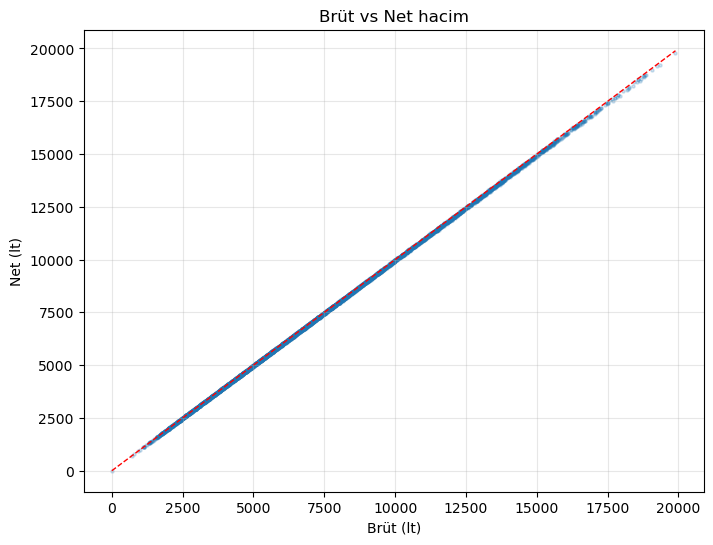

Brüt-Net fark istatistikleri:
count    137954.000000
mean         37.309531
std          25.418638
min         -23.720000
25%          18.660000
50%          31.350000
75%          49.470000
max         202.900000
Name: brut_net_fark, dtype: float64


In [2]:
# Brüt vs Net
fig, ax = plt.subplots(figsize=(8, 6))
sample = inv.dropna(subset=['urun_miktari_net']).sample(min(5000, len(inv)), random_state=42)
ax.scatter(sample['urun_miktari_brut'], sample['urun_miktari_net'], alpha=0.2, s=5)
ax.plot([0, sample['urun_miktari_brut'].max()], [0, sample['urun_miktari_brut'].max()], 'r--', lw=1)
ax.set_xlabel('Brüt (lt)'); ax.set_ylabel('Net (lt)')
ax.set_title('Brüt vs Net hacim')
plt.show()

print('Brüt-Net fark istatistikleri:')
print(inv['brut_net_fark'].describe())

In [3]:
# Su seviyesi — sıfır olmayan tank-günler
su_pos = inv[inv['su_seviyesi_cm'].fillna(0) > 0.5]
print('Su > 0.5 cm satır:', len(su_pos))
if len(su_pos):
    su_tank = su_pos.groupby(['istasyon_kodu','tank_no']).size().sort_values(ascending=False)
    print('En çok su kaydı olan tanklar:')
    print(su_tank.head(10))

Su > 0.5 cm satır: 137785
En çok su kaydı olan tanklar:
istasyon_kodu  tank_no
IST_001        1          4320
IST_003        2          4320
IST_008        2          4320
               1          4320
IST_006        4          4320
               2          4320
               1          4320
IST_004        3          4320
               2          4320
               1          4320
dtype: int64


In [4]:
# Su artış hızı — su faktörü adayı
inv2 = inv.sort_values(['istasyon_kodu','tank_no','envanter_tarihi']).copy()
inv2['su_diff'] = inv2.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()
spike = inv2[inv2['su_diff'] > 0.05]
print('Su sıçrama (>0.05 cm/30dk) satır:', len(spike))
if len(spike):
    display(spike.nlargest(10, 'su_diff')[['envanter_tarihi','istasyon_kodu','tank_no','su_seviyesi_cm','su_diff']])

Su sıçrama (>0.05 cm/30dk) satır: 85


,envanter_tarihi,istasyon_kodu,tank_no,su_seviyesi_cm,su_diff
36184,2026-03-02 18:30:00,IST_002,5,14.476,14.476
36182,2026-03-02 18:30:00,IST_002,3,5.873,5.873
16116,2026-03-09 04:00:00,IST_001,2,5.861,5.861
36180,2026-03-02 18:30:00,IST_002,1,5.617,5.617
36181,2026-03-02 18:30:00,IST_002,2,5.210,5.210
36183,2026-03-02 18:30:00,IST_002,4,4.958,4.958
31729,2026-02-12 05:00:00,IST_002,5,11.271,0.062
31799,2026-02-12 12:00:00,IST_002,5,11.987,0.062
31679,2026-02-12 00:00:00,IST_002,5,10.819,0.061
31154,2026-02-09 19:30:00,IST_002,5,5.879,0.061


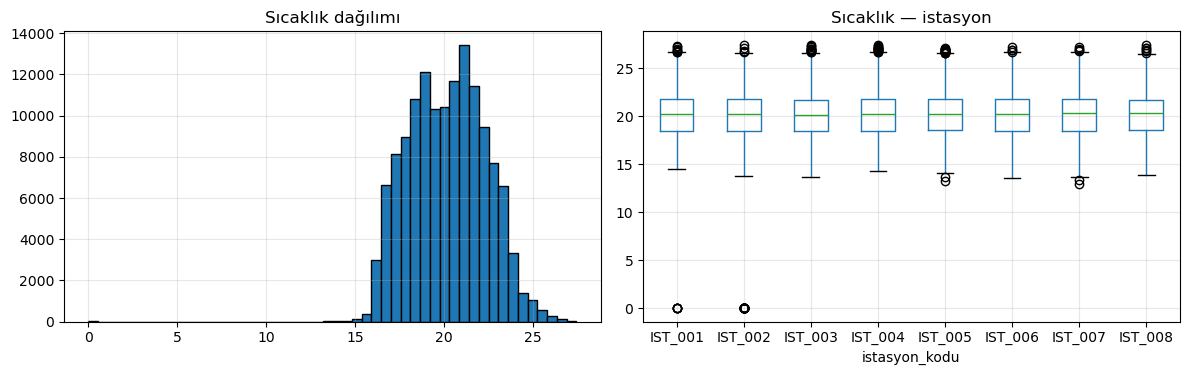

In [5]:
# Sıcaklık dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inv['sicaklik'].dropna().hist(bins=50, ax=axes[0], edgecolor='k')
axes[0].set_title('Sıcaklık dağılımı')
inv.boxplot(column='sicaklik', by='istasyon_kodu', ax=axes[1])
axes[1].set_title('Sıcaklık — istasyon')
plt.suptitle('')
plt.tight_layout()
plt.show()

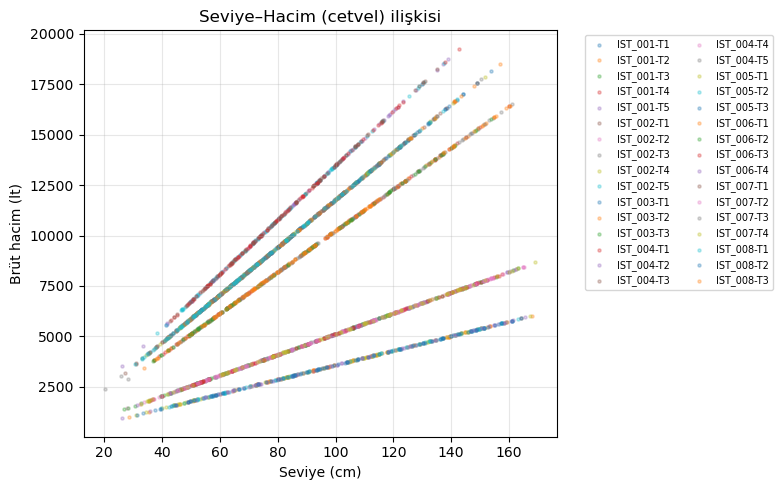

In [6]:
# Seviye (cm) vs hacim (lt) — strapping ilişkisi
sample = inv.dropna(subset=['urun_seviyesi_cm','urun_miktari_brut']).sample(min(3000,len(inv)), random_state=1)
plt.figure(figsize=(8, 5))
for (ist, tn), g in sample.groupby(['istasyon_kodu','tank_no']):
    if len(g) > 20:
        plt.scatter(g['urun_seviyesi_cm'], g['urun_miktari_brut'], alpha=0.3, s=5, label=f'{ist}-T{tn}')
plt.xlabel('Seviye (cm)'); plt.ylabel('Brüt hacim (lt)')
plt.title('Seviye–Hacim (cetvel) ilişkisi')
plt.legend(bbox_to_anchor=(1.05,1), fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

Sonraki: satış ve dolum (`07_satis_ve_dolum.ipynb`).